In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly
import math 


# 1. Business Understanding

The objective of this project is to predict whether an online shopper is likely to complete a purchase based on their browsing behaviour during a website session and other factors. By identifying customers with high purchase intention, businesses can provide personalised recommendations, targeted promotions, or reminders to improve conversion rates while reducing unnecessary marketing costs.

This is a binary classification problem because the target variable, Revenue, has only two possible outcomes: True (Purchase) and False (No Purchase). Although the model predicts one of these two classes, it can also output the probability of purchase (e.g., 82%), giving businesses a better understanding of how likely a customer is to make a purchase. The final prediction is still based on these two classes, so the problem remains a binary classification task rather than a regression problem.

Small note is that from the bussines understanding:<mark>Recall and precision is important since we care about why is actually buys the project </mark>

# 2. Data Understanding

Before anything could start we have to know why use this dataset and if it is save to use(what makes a good datasets)
So here i am using a data set from link:https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset and it is call Online Shoppers Purchasing Intention Dataset. and i will be giving edvidence on why this dataset is good or safe to use

1) it is hosted by the official UCI Machine Learning Repository
2) it has the creator C.Sakar and Yomi Kastro's names 
3) it has permanent DOI which let people locate the official datasets 
4) it is linked to a published research paper (extemly imporant) Springer’s    Neural Computing and Applications, volume 31, pages 6893–6908.
5) the data collection was well explained 
6) each featurs is well explain and it tells why it might affect results 
7) it has a legal licence 
   -Creative Commons Attribution 4.0 International
   -CC BY 4.0

## 2.1 Load dataset

In [4]:
# just getting the data and have a look frist 
FILE_PATH = "online_shoppers_intention.csv"
df = pd.read_csv(FILE_PATH) 
df 

# this is a copy of the dataset this allow us to check and compare at anypoint of the project 
copy_df = df.copy()



# traget: revenue - True/False 

| Column | Description |
|--------|-------------|
| **Administrative** | Number of administrative pages visited (e.g., login, account, checkout). |
| **Administrative_Duration** | Total time (seconds) spent on administrative pages. |
| **Informational** | Number of informational pages visited (e.g., About Us, Contact, Privacy Policy). |
| **Informational_Duration** | Total time (seconds) spent on informational pages. |
| **ProductRelated** | Number of product-related pages visited (e.g., product details or category pages). |
| **ProductRelated_Duration** | Total time (seconds) spent on product-related pages. |
| **BounceRates** | Percentage of visitors who entered the website on a page and left without visiting any other page. |
| **ExitRates** | Percentage of times a page was the last page viewed before leaving the website. |
| **PageValues** | A value indicating how much a page contributed to a purchase. Higher values suggest the page is more likely to lead to a sale. |
| **SpecialDay** | A value between **0.0** and **1.0** indicating how close the session was to a special shopping day or holiday. |
| **Month** | Month in which the browsing session occurred. |
| **Weekend** | Indicates whether the browsing session occurred on a weekend (**True/False**). |
| **OperatingSystems** | Anonymous ID representing the user's operating system (e.g., Windows, macOS, Android). |
| **Browser** | Anonymous ID representing the user's web browser (e.g., Chrome, Safari, Firefox). |
| **Region** | Anonymous ID representing the geographic region of the user. |
| **TrafficType** | Anonymous ID representing how the user arrived at the website (e.g., search engine, advertisement, direct visit). |
| **VisitorType** | Type of visitor: **New_Visitor**, **Returning_Visitor**, or **Other**. |

In [5]:
# get the rows and col 
number_of_rows, number_of_columns = df.shape
print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)


number_of_features = number_of_columns - 1    # -1 as the target is not counted 
row_feature_ratio = number_of_rows / number_of_features

print(f"Approximately {row_feature_ratio:.1f} rows for every feature.")

Number of rows: 12330
Number of columns: 18
Approximately 725.3 rows for every feature.


### Data Quantity

To ensure that there is sufficient data for model training, the <mark>**row to feature ratio**</mark> was calculated. This ratio indicates how many training examples are available for each feature.

Our dataset has approximately <mark>**752 rows per feature**</mark> .This suggests that the dataset contains enough observations for the model to learn meaningful patterns and reduces the risk of having too little data relative to the number of features.

<Mark>**Summary:** The dataset meets the recommended data quantity guideline, so no additional data collection or feature reduction is required based on dataset size.</mark>

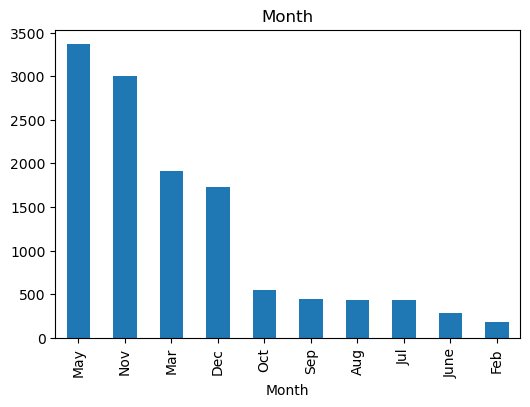

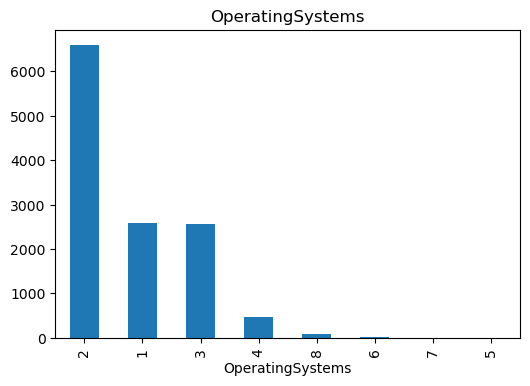

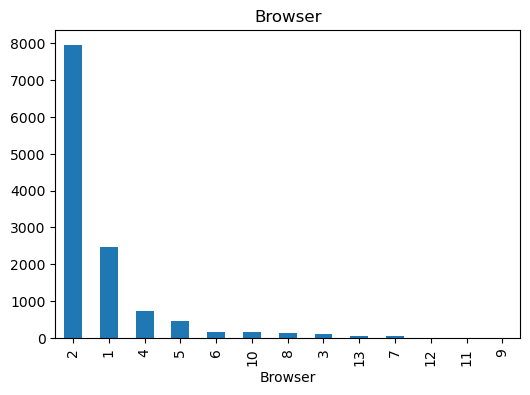

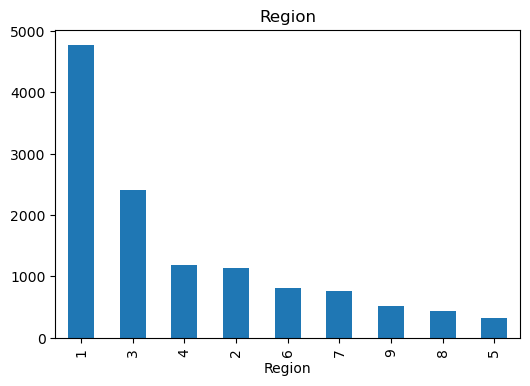

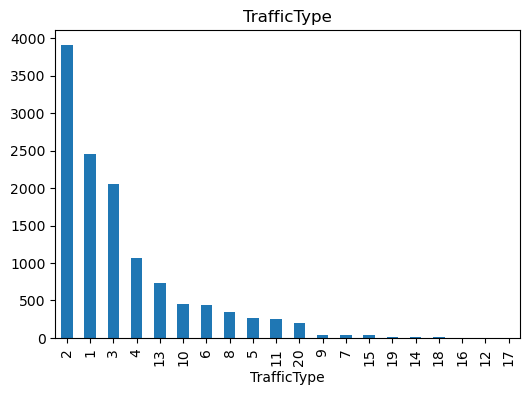

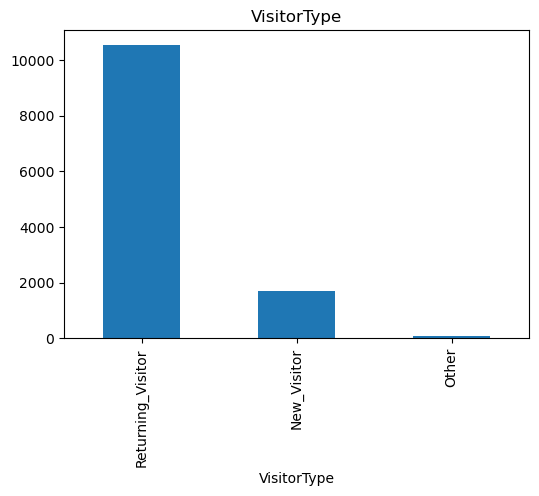

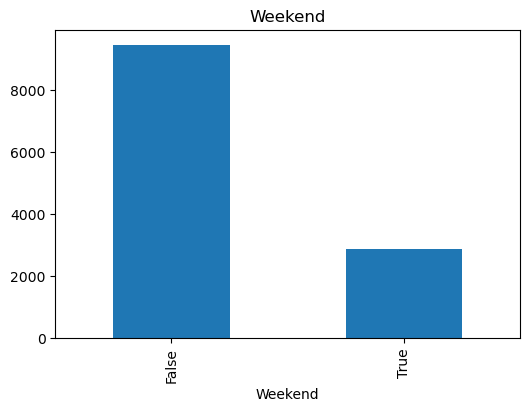

In [6]:
import matplotlib.pyplot as plt

# cols 
categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

# for loop to show all 
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()


### Dataset Diversity

The bar charts above were used to examine the distribution of the categorical features in the dataset.

- **Month:** Most sessions occurred in May and November, while some months have much fewer records.
- **OperatingSystems:** Operating system category `2` appears much more frequently than the other categories.
- **Browser:** Browser category `2` is dominant, while several browser categories contain very few observations.
- **Region:** Region category `1` has the highest number of sessions.
- **TrafficType:** Traffic type category `2` is the most common, although the feature still contains many different traffic sources.
- **VisitorType:** Most sessions came from `Returning_Visitor`, while `New_Visitor` and `Other` are less common.
- **Weekend:** Most browsing sessions occurred on weekdays rather than weekends.

Having dominant categories does not automatically indicate a data-quality problem. Real-world customer data is often uneven because certain devices, visitor types, regions, or traffic sources are naturally more common than others. However, these imbalances may cause the model to learn more strongly from the common categories and less reliably from categories with very few observations.

I initially considered removing the **Browser** feature because it was unclear how a browser could influence purchasing behaviour. However, the browser may indirectly represent differences in device usage, customer behaviour, website compatibility, or user experience. Since the browser values are anonymous category IDs, their actual browser names cannot be assumed. Therefore, the feature will be retained initially and its usefulness will be evaluated later using model performance and feature importance.

In [7]:
## Check for missing data
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_report = missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_report)

# ok this dataset was already told that it has no missing values but it is still important to check 

,missing_count,missing_percentage
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


In [8]:
#outliers

numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

# print numbers for me to see 
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)] # lower/high 
    print(f"{col}: {len(outliers)} outliers")


# so from this part i do see that i have outliers and i have to decide which to clear later with the box plot and other methods 
#such as the z score and the IQR 


Administrative: 404 outliers
Administrative_Duration: 1172 outliers
Informational: 2631 outliers
Informational_Duration: 2405 outliers
ProductRelated: 987 outliers
ProductRelated_Duration: 961 outliers
BounceRates: 1551 outliers
ExitRates: 1099 outliers
PageValues: 2730 outliers
SpecialDay: 1251 outliers


## Outliers problem
so from this part i do see that i have outliers(need to dive more) and i have to decide which to clear later with the box plot and other methods such as the z score and the IQR 

In [9]:
# unique col 
unique_value_report = pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_percentage": (
        df.nunique(dropna=False) /
        len(df) * 100
    ),
    "example_values": [
        df[column].drop_duplicates().head(10).tolist()
        for column in df.columns
    ]
})

display(
    unique_value_report.sort_values(
        "unique_count"
    )
)


## insights for unqiue cols 
#1)
#-Revenue, Weekend, VisitorType, SpecialDay, operatingSystems
#-Region, Month, Browser, TrafficType These values has such an low unique count
#-meaning even if we apply OHE for the col we dont have to worry about curse of dimensionality (at the samne time our rows are enough)

#2) 
#-Informational has 17 unique values, Administrative has 27, 
#-but ProductRelated jumps all the way up to 311 unique values (2.52%).
#-this shows not many people go to administrative page since they are here to shope
#-This high variation means ProductRelated page have stronger indicator of user intent 
#-this part might help me with the feature engineering later 

#3)
#-Durations (Informational, Administrative, ProductRelated), BounceRates, ExitRates, PageValues
#-this just shows that everyone spents different time which is important it shows that it is real data 

,unique_count,unique_percentage,example_values
Revenue,2,0.016221,"[False, True]"
Weekend,2,0.016221,"[False, True]"
VisitorType,3,0.024331,"[Returning_Visitor, New_Visitor, Other]"
SpecialDay,6,0.048662,"[0.0, 0.4, 0.8, 1.0, 0.2, 0.6]"
OperatingSystems,8,0.064882,"[1, 2, 4, 3, 7, 6, 8, 5]"
Region,9,0.072993,"[1, 9, 2, 3, 4, 5, 6, 7, 8]"
Month,10,0.081103,"[Feb, Mar, May, Oct, June, Jul, Aug, Nov, Sep,..."
Browser,13,0.105434,"[1, 2, 3, 4, 5, 6, 7, 10, 8, 9]"
Informational,17,0.137875,"[0, 1, 2, 4, 16, 5, 3, 14, 6, 12]"
TrafficType,20,0.162206,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


In [10]:
# show constent 
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)

#Constant columns should normally be removed because:
#They provide no predictive information
#They add unnecessary complexity
#They may interfere with some statistical calculations
#Their variance is zero
# but for this it seems like we dont have this problem for our datasets 

Constant columns: []


In [11]:
# show duplicates 

duplicate_count = df.duplicated().sum()
duplicate_percentage = df.duplicated().mean() * 100

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%" # how many percent 
)

# here tells me that i have duplicate rows and i should clear them up later in the data cleaning as it prevents data leakage
# we dw the model to remember the data and become overfitting if they can remember the rows when we split into train test set later 

Duplicate rows: 125
Duplicate percentage: 1.01%


In [12]:
# inconsistent for catergorical 

for col in categorical_cols:
    print(df[col].unique()) 

# good there is no inconsistent 

['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
[1 2 4 3 7 6 8 5]
[ 1  2  3  4  5  6  7 10  8  9 12 13 11]
[1 9 2 3 4 5 6 7 8]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
['Returning_Visitor' 'New_Visitor' 'Other']
[False  True]


In [13]:
## Understand the type of variable for each column
data_type_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "example_values": [
        df[column].drop_duplicates().head(5).tolist()
        for column in df.columns
    ]
})

display(data_type_report)


,data_type,example_values
Administrative,int64,"[0, 1, 2, 4, 12]"
Administrative_Duration,float64,"[0.0, 53.0, 64.6, 6.0, 18.0]"
Informational,int64,"[0, 1, 2, 4, 16]"
Informational_Duration,float64,"[0.0, 120.0, 16.0, 94.0, 93.0]"
ProductRelated,int64,"[1, 2, 10, 19, 0]"
ProductRelated_Duration,float64,"[0.0, 64.0, 2.666666667, 627.5, 154.2166667]"
BounceRates,float64,"[0.2, 0.0, 0.05, 0.02, 0.015789474]"
ExitRates,float64,"[0.2, 0.1, 0.14, 0.05, 0.024561404]"
PageValues,float64,"[0.0, 54.17976426, 19.44707913, 38.30849268, 2..."
SpecialDay,float64,"[0.0, 0.4, 0.8, 1.0, 0.2]"


## important for later 

#
-The OperatingSystems, Browser, Region, and TrafficType.(1, 2, 3, 4), but the data_type is correctly listed as category.this means the machine will not treat them as order but it is a group which is good (this part is false after later on the describe i reliazed this is wrong as the machine still treat these numbers as numeric)
# 
-There is a lot of 0.0 for Administrative	Administrative_Duration	Informational	Informational_Duration,this tells us that normal customer dont go to these page and won't even stay and also how the graph might look like later 
#
-BounceRates, ExitRates, and PageValues are all float64 these are important indicators from the col understanding


<mark>things to do later(not fully but now we at least know some)</mark>
# 
-Encode Categorical Variables(visitory type,month and weekend) machine learning algorithms only understand numbers and how we might be able to create new features 

# summary of things i did for the bussines and data understanding 

In [14]:
# 1)so we dfine what we want for the bussiness
# 2)I done the 4 check: Relevant,quality,quantity and diversity making sure they are all ok 
# 3)then I get  to know the types of the datas
# 4) I check for missing which my dataset dont have 
# 5) I check for outliers which have 
# 6) I check for Unique coluns and consant 
# 7) I check for duplicates which also have 
# 8) I check for inconsistent which dont have 

## Steps to do after understanding the data 


In [15]:
# at this point i have some basic understanding of what my data is and we will start cleaing the dataset 
# but we actually going to performe data cleaning 2 times, frist is before EDA and after EDA to make sure 
# i have a perfectly clean data for me to use later 
# things to clean for this part: duplicates 

df = df.drop_duplicates()
print(f"The number of duplicates left is {df.duplicated().sum()}")

# outliers and the datatypes we will do it after EDA 

The number of duplicates left is 0


## 2.3 EDA

## 2.3.1 basic EDA without visulizations yet 

In [16]:
## Describe data distribution 
df.describe(include='all')


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205,12205.000000,12205.000000,12205.000000,12205.000000,12205,12205,12205
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3329,NaN,NaN,NaN,NaN,10431,9346,10297
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,NaN,2.124211,2.357804,3.153298,4.073904,NaN,NaN,NaN
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,NaN,0.906823,1.710114,2.402340,4.016654,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


### Data Insights

#### 1. Categorical Features Stored as Numbers

The features **OperatingSystems**, **Browser**, **Region**, and **TrafficType** contain numerical values such as `1`, `2`, `3`, and `4`, but these values represent categories rather than quantities for example, a larger browser ID does not mean that one browser is better or greater than another therefore, these features should be treated as **nominal categorical variables** rather than ordered numerical variables,although their data type is currently listed as `category`, this alone does not guarantee that a machine learning model will interpret them correctly. They will still need to be encoded before model training.(things to do)

#### 2. Many Zero Values in Page-Visit Features
The features **Administrative**, **Administrative_Duration**, **Informational**, and **Informational_Duration** contain many `0` values,this meams that many visitors did not visit administrative or informational pages during their browsing sessions. For example, a customer may only browse product pages without visiting pages such as account, contact, or company information pages.These zero values are likely valid browsing behaviour rather than missing data. They may also cause the distributions of these features to be strongly right-skewed, with many values concentrated near zero.

#### 3. Important Continuous Behaviour Indicators
- **BounceRates** 
- **ExitRates** 
- **PageValues** 
These features may be useful for identifying whether a visitor is showing strong or weak purchase intention.

### Steps to Perform Later

#### 1. Encode Categorical Variables

Categorical features must be converted into a numerical format before they can be used by most machine learning algorithms.

- `Month`
- `VisitorType`
- `OperatingSystems`
- `Browser`
- `Region`
- `TrafficType`

The `Weekend` feature can be converted from `True/False` into `1/0`.
these are the encoding things we have to do 

#### 2. Consider Feature Engineering
New features may be created later to represent customer browsing behaviour more clearly. Possible examples include:
- Average time spent per administrative page
- Average time spent per informational page
- Average time spent per product-related page
- Total number of pages visited
- Total browsing duration
these might be the things we going to do,we will decide later 

In [17]:
df.info()
# after applying this i find it a bit useless as we already know all these informations but it's ok we will just keep
# at least it tells us how many of the datatypes are there 

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

## 2.3.2 Exploratory Data Analysis

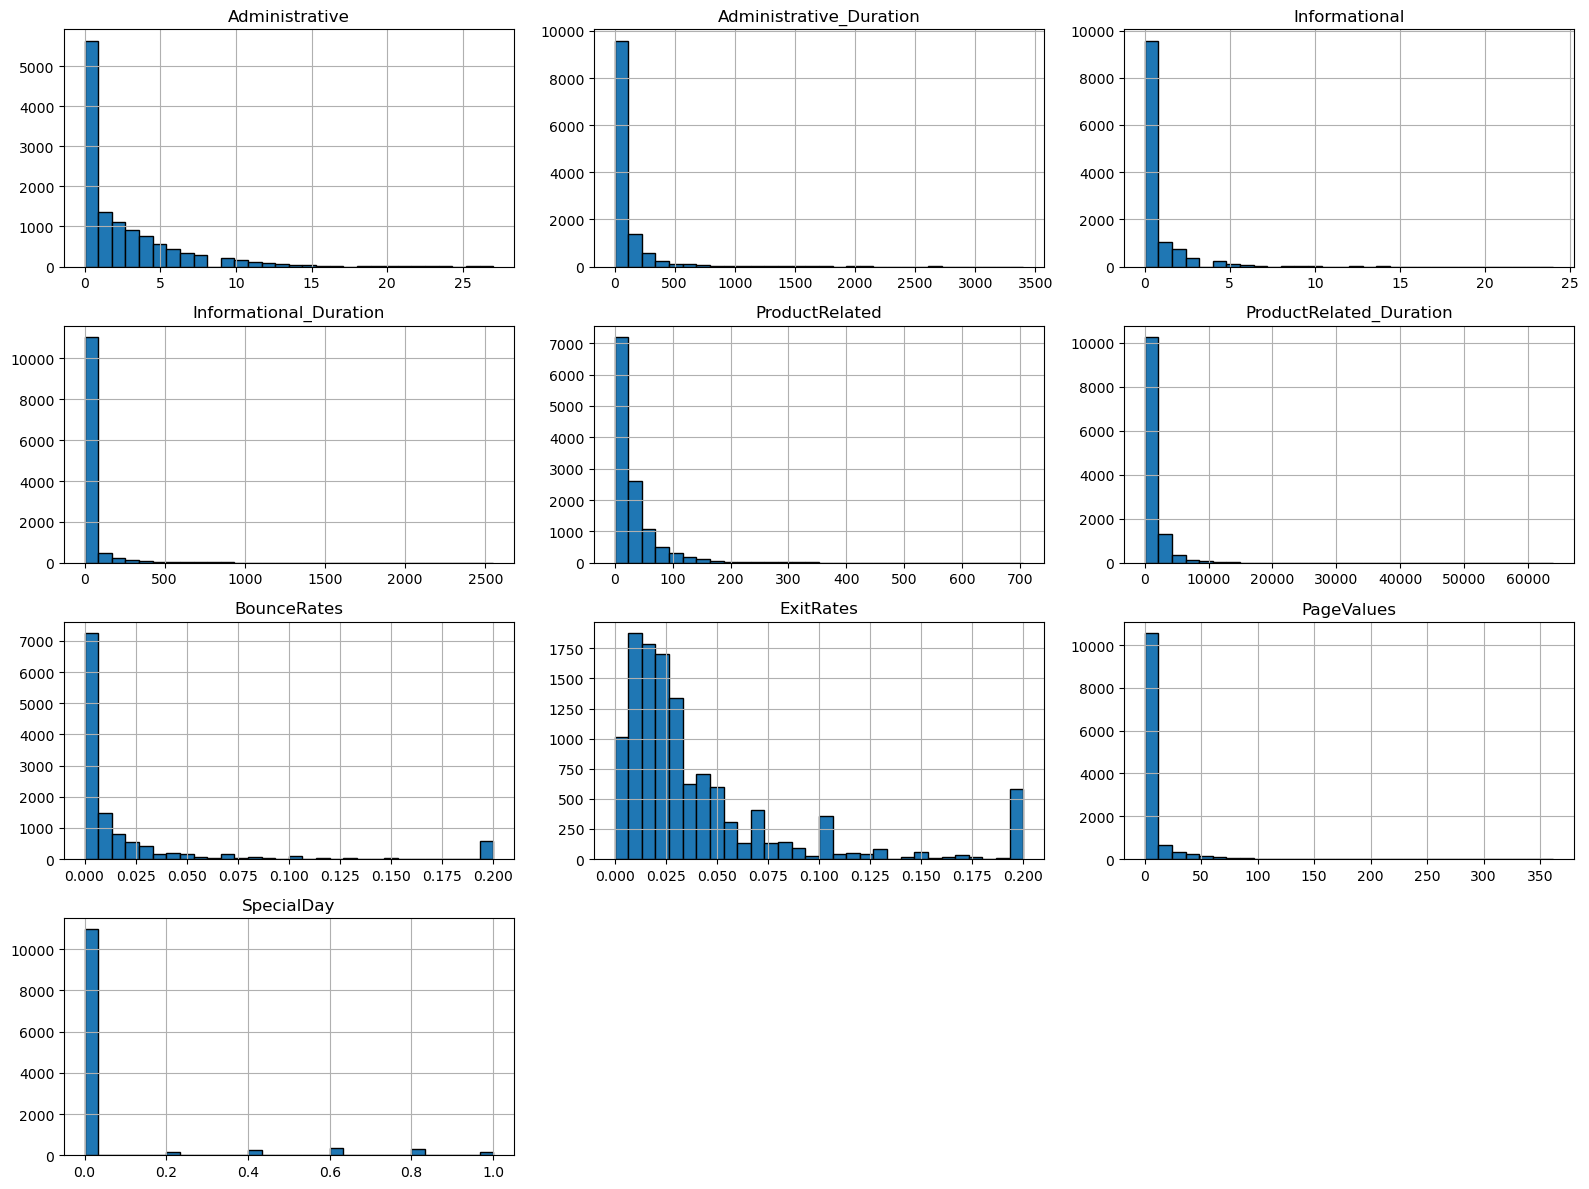

In [18]:
# we will apply visuals now starting from univariate analysis=studies one variable to understand distribution
# historgram 

df[numeric_cols].hist(
    bins=30,
    figsize=(16, 12),
    edgecolor='black'
)


plt.tight_layout()
plt.show()


## insights from the graph 
the y left is the rows and the x is the cols 
insights: 
 1) Almost all numerical columns are strongly right-skewed.
#
 2) Most sessions have small or zero values, while a small number of sessions have very large values
# 
 3) they also tells me there is possible outliers but we will only remove real outliers 

<mark>Important !!!</mark> 
#
 4) Frist as most data is small at the right side, 2 things to take note,extrem large numbers can affect some models therefore we might use "np.log1p()" which compress big numbers into smaller ones while perserving the order

 5) we also might create binary indicators later 

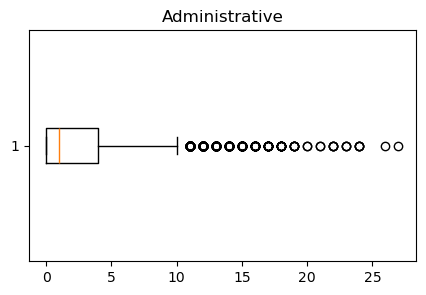

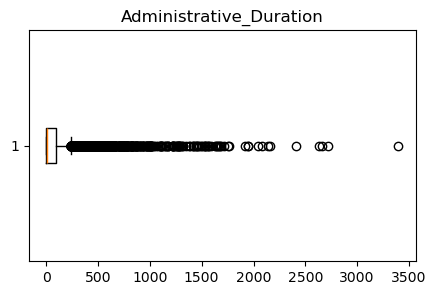

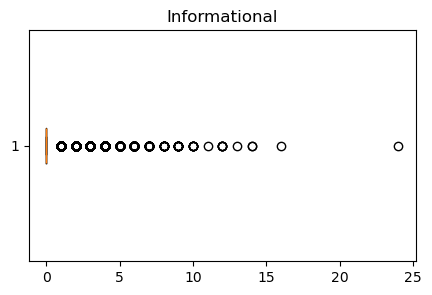

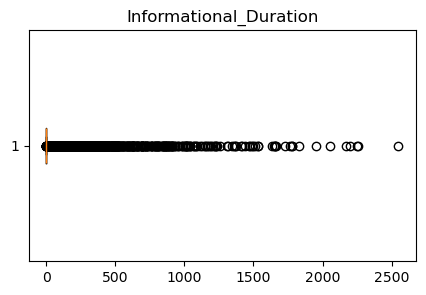

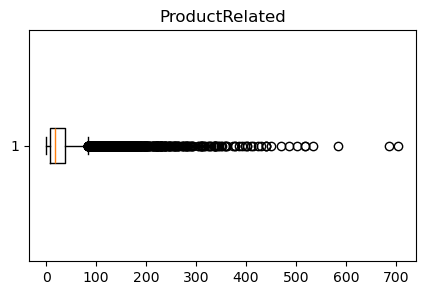

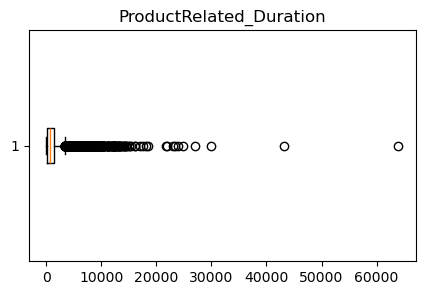

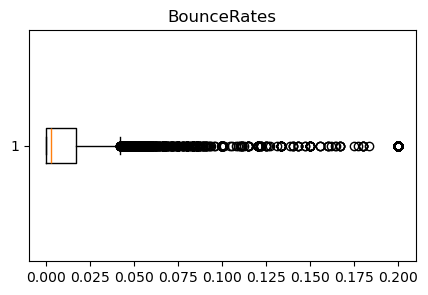

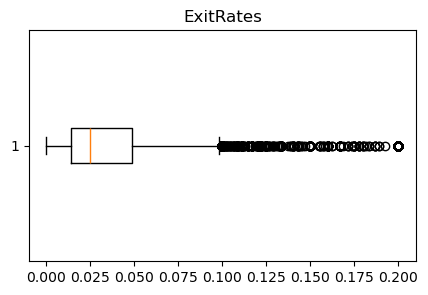

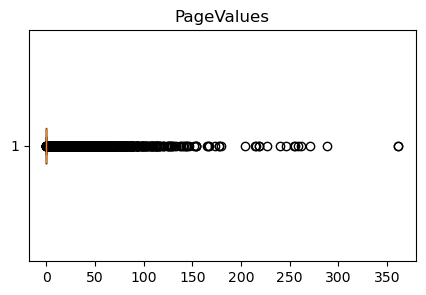

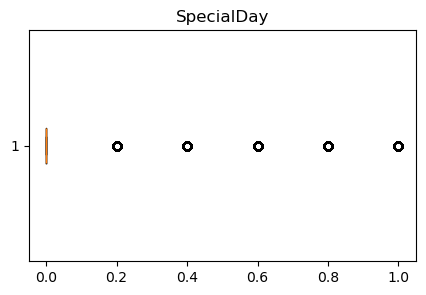

In [19]:
# box plot for outliers 

# for me to see in box plot 
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

# so at this point i had a hard time deciding if the outliers are vaild or not and also hard to see 
# so i decided to research and do a robust z score- considering my graph have outliers and my histogram is right skewed
# i will be using median,log transformation and MAD(median absolute deviation) to calculate the robust z-score
# and also pair with IQR method on top before the EDA (i did it at the dataunderstanding)
# which helps me to quickly identify outliers  

In [20]:
# here is a robust z score i will use this and the IQR we did at data understanding to handler outliers 
def flag_log_mad_outliers(
    series,
    threshold=3.5
):
    # Create a False flag for every row initially
    flags = pd.Series(
        False,
        index=series.index
    )
    scores = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )
    # Analyse positive values separately
    positive_values = series[
        series > 0
    ]

    # Compress the strongly skewed values
    log_values = np.log1p(
        positive_values
    )

    median = log_values.median()

    mad = (
        log_values - median
    ).abs().median()

    # Avoid dividing by zero
    if mad == 0:
        return flags, scores

    robust_z_scores = (
        0.6745
        * (log_values - median)
        / mad
    )

    # We are mainly interested in the extreme upper tail
    flags.loc[
        robust_z_scores.index
    ] = robust_z_scores > threshold

    scores.loc[
        robust_z_scores.index
    ] = robust_z_scores

    return flags, scores

pagevalue_flags, pagevalue_scores = (
    flag_log_mad_outliers(
        df['ExitRates']
    )
)

numeric_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

for col in numeric_cols:

    flags, scores = flag_log_mad_outliers(df[col])

    print("=" * 60)
    print(f"{col}")
    print(f"Potential outliers: {flags.sum()}")

    display(
        df.loc[
            flags,
            [col, 'Revenue']
        ]
        .assign(Robust_Z_Score=scores[flags])
        .sort_values(
            col,
            ascending=False
        )
        .head(20)
    )


Administrative
Potential outliers: 0


,Administrative,Revenue,Robust_Z_Score


Administrative_Duration
Potential outliers: 0


,Administrative_Duration,Revenue,Robust_Z_Score


Informational
Potential outliers: 1


...

,ExitRates,Revenue,Robust_Z_Score
12321,0.2,False,7.793188
0,0.2,False,7.793188
2,0.2,False,7.793188
12301,0.2,False,7.793188
6,0.2,False,7.793188
7,0.2,False,7.793188
16,0.2,False,7.793188
21,0.2,False,7.793188
24,0.2,False,7.793188
11998,0.2,False,7.793188


PageValues
Potential outliers: 0


,PageValues,Revenue,Robust_Z_Score


SpecialDay
Potential outliers: 0


,SpecialDay,Revenue,Robust_Z_Score


## Decisions on how to handle outliers 

why is my data saying 2 different things: as my dataset is haveily right-skewed, contain many zeros, are discrete, or have fixed upper limits

so from the informations we got the IQR says we have a lot of outliers which is we are not going to follow blindy as if clearing 
those much outliers will 100% reduce my datasets, so the robust R score (made by using log transformation to squish the big numbers and use median and MAD which will not get affected by the big numbers to make this) tells me the other hand, it tells me that i almost has no outliers.So my finial decision: 

follow based on my domain knowledage which i explained at the z score part instead on these data

<mark>Actions to be done later :    <mark>

At this stage, the statistical outlier results did not always match my understanding of normal online shopping behaviour. Therefore, I decided not to remove values based only on the statistical method and instead considered whether each value was realistic and relevant to the business context.

For `SpecialDay`, `BounceRates`, `ExitRates`, and `PageValues`, all identified outliers will be retained. There is not enough evidence to prove that these values are incorrect. They may represent rare but valid shopping sessions rather than data errors. Some values appear unusual mainly because common values, such as `0`, occur very frequently in the dataset.

The outliers found in `Administrative`, `Administrative_Duration`, `Informational`, and `Informational_Duration` will also be retained. Although some values are much higher than the majority, they still appear possible, and there is insufficient evidence to justify removing them.

However, some extreme values in `ProductRelated` and `ProductRelated_Duration` appear less realistic. Several sessions recorded approximately **14.5 to 17 hours** of product browsing, which may indicate that the webpage was left open rather than the user actively shopping. Therefore, these extreme duration values will be removed.

Sessions with more than **450 product-related page visits** will also be removed. Even if a visitor spent only one minute on each page, this would require more than **7.5 hours** of continuous browsing. This threshold is based on business reasoning and will be clearly documented as an assumption.

Overall, outliers will only be removed when there is a reasonable business justification that the values may not represent genuine active shopping behaviour.

In [21]:
# bar char
# i already have it on the top while looking at diversity so wont do it again

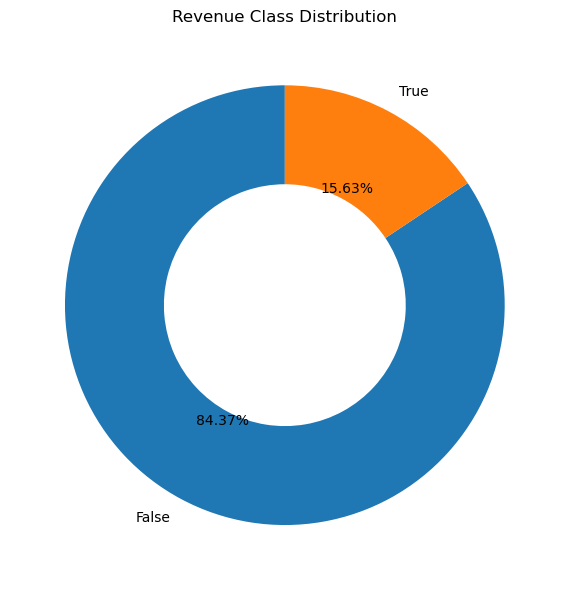

In [22]:
# distribution of the revenue 
target_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    target_counts.values,
    labels=target_counts.index.astype(str),
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Revenue Class Distribution")
plt.tight_layout()
plt.show()

## insights:
 i already know this problem on top but now we just make a pie to show the disturibution to show it we already talk about this in the privous part and why this is a problem 
 and accuracy might be msileading so use precision,recall,F1-score, even F2 ,precision-recall AUC,confusion matrix,balanced accuracy. 

## EDA Exploratory Data Analysis  Bivariate Analysis

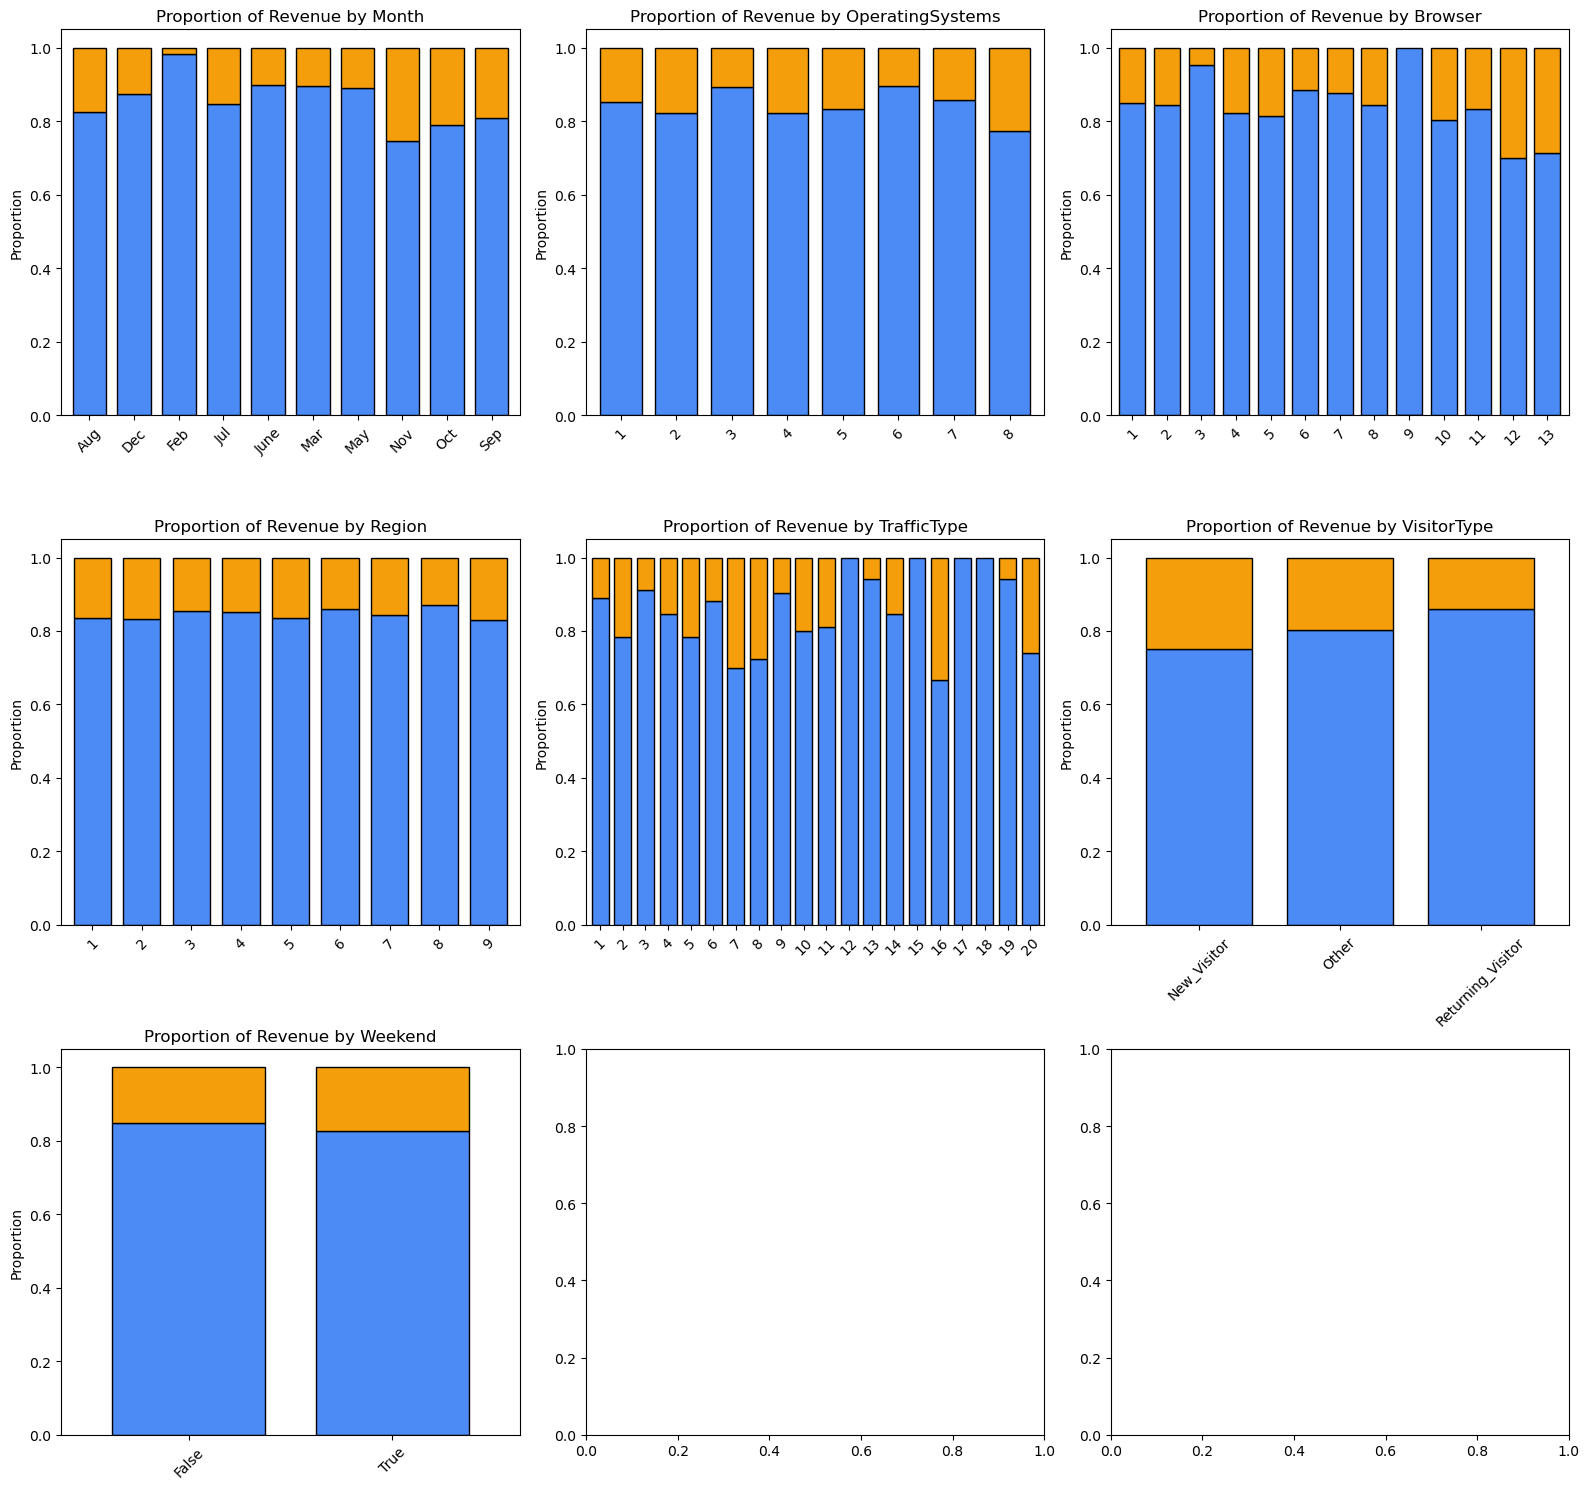

In [23]:
# a clean 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 15))
axes = axes.flatten()
TARGET = "Revenue"

# proportions and plot using Pandas native stacked bars
for i, col in enumerate(categorical_cols):
    # 'normalize="index"' turns the raw counts into a perfect 0.0 to 1.0 proportion
    crosstab = pd.crosstab(df[col], df[TARGET], normalize="index")

    # Plot as a stacked bar
    crosstab.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        edgecolor="black",
        width=0.75,
        color=["#4c8bf5", "#f59e0b"], 
    )

    axes[i].set_title(f"Proportion of Revenue by {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].get_legend().remove() 

# the 2 empty is cuase it is 3x3 

plt.tight_layout()
plt.show()

### Categorical Feature Insights

From the categorical feature analysis, `VisitorType`, `Region`, and `Weekend` appear to have only a weak relationship with whether a user makes a purchase. `Weekend` may have a small effect, while the result for `VisitorType` was more surprising than expected.

The results for `OperatingSystems` and `Browser` should be interpreted carefully because most users are concentrated in only a few categories. Therefore, high purchase counts may simply be caused by having more users in those groups rather than a higher purchase likelihood.

`Month` shows a noticeable difference, especially in November, which has a relatively high purchase proportion. This may be related to major online shopping events such as 11.11, although this is only a possible explanation.

`TrafficType` appears useful because customers arriving through different traffic sources show different purchase rates. This suggests that the method used to reach the website may influence purchase intention.
i also realized that the nov has a good proprtion which might be because of 11.11 and all kinds of dues given out and the traffic type is quite important as it tells us different users using different ways to search for items have different buy rate 





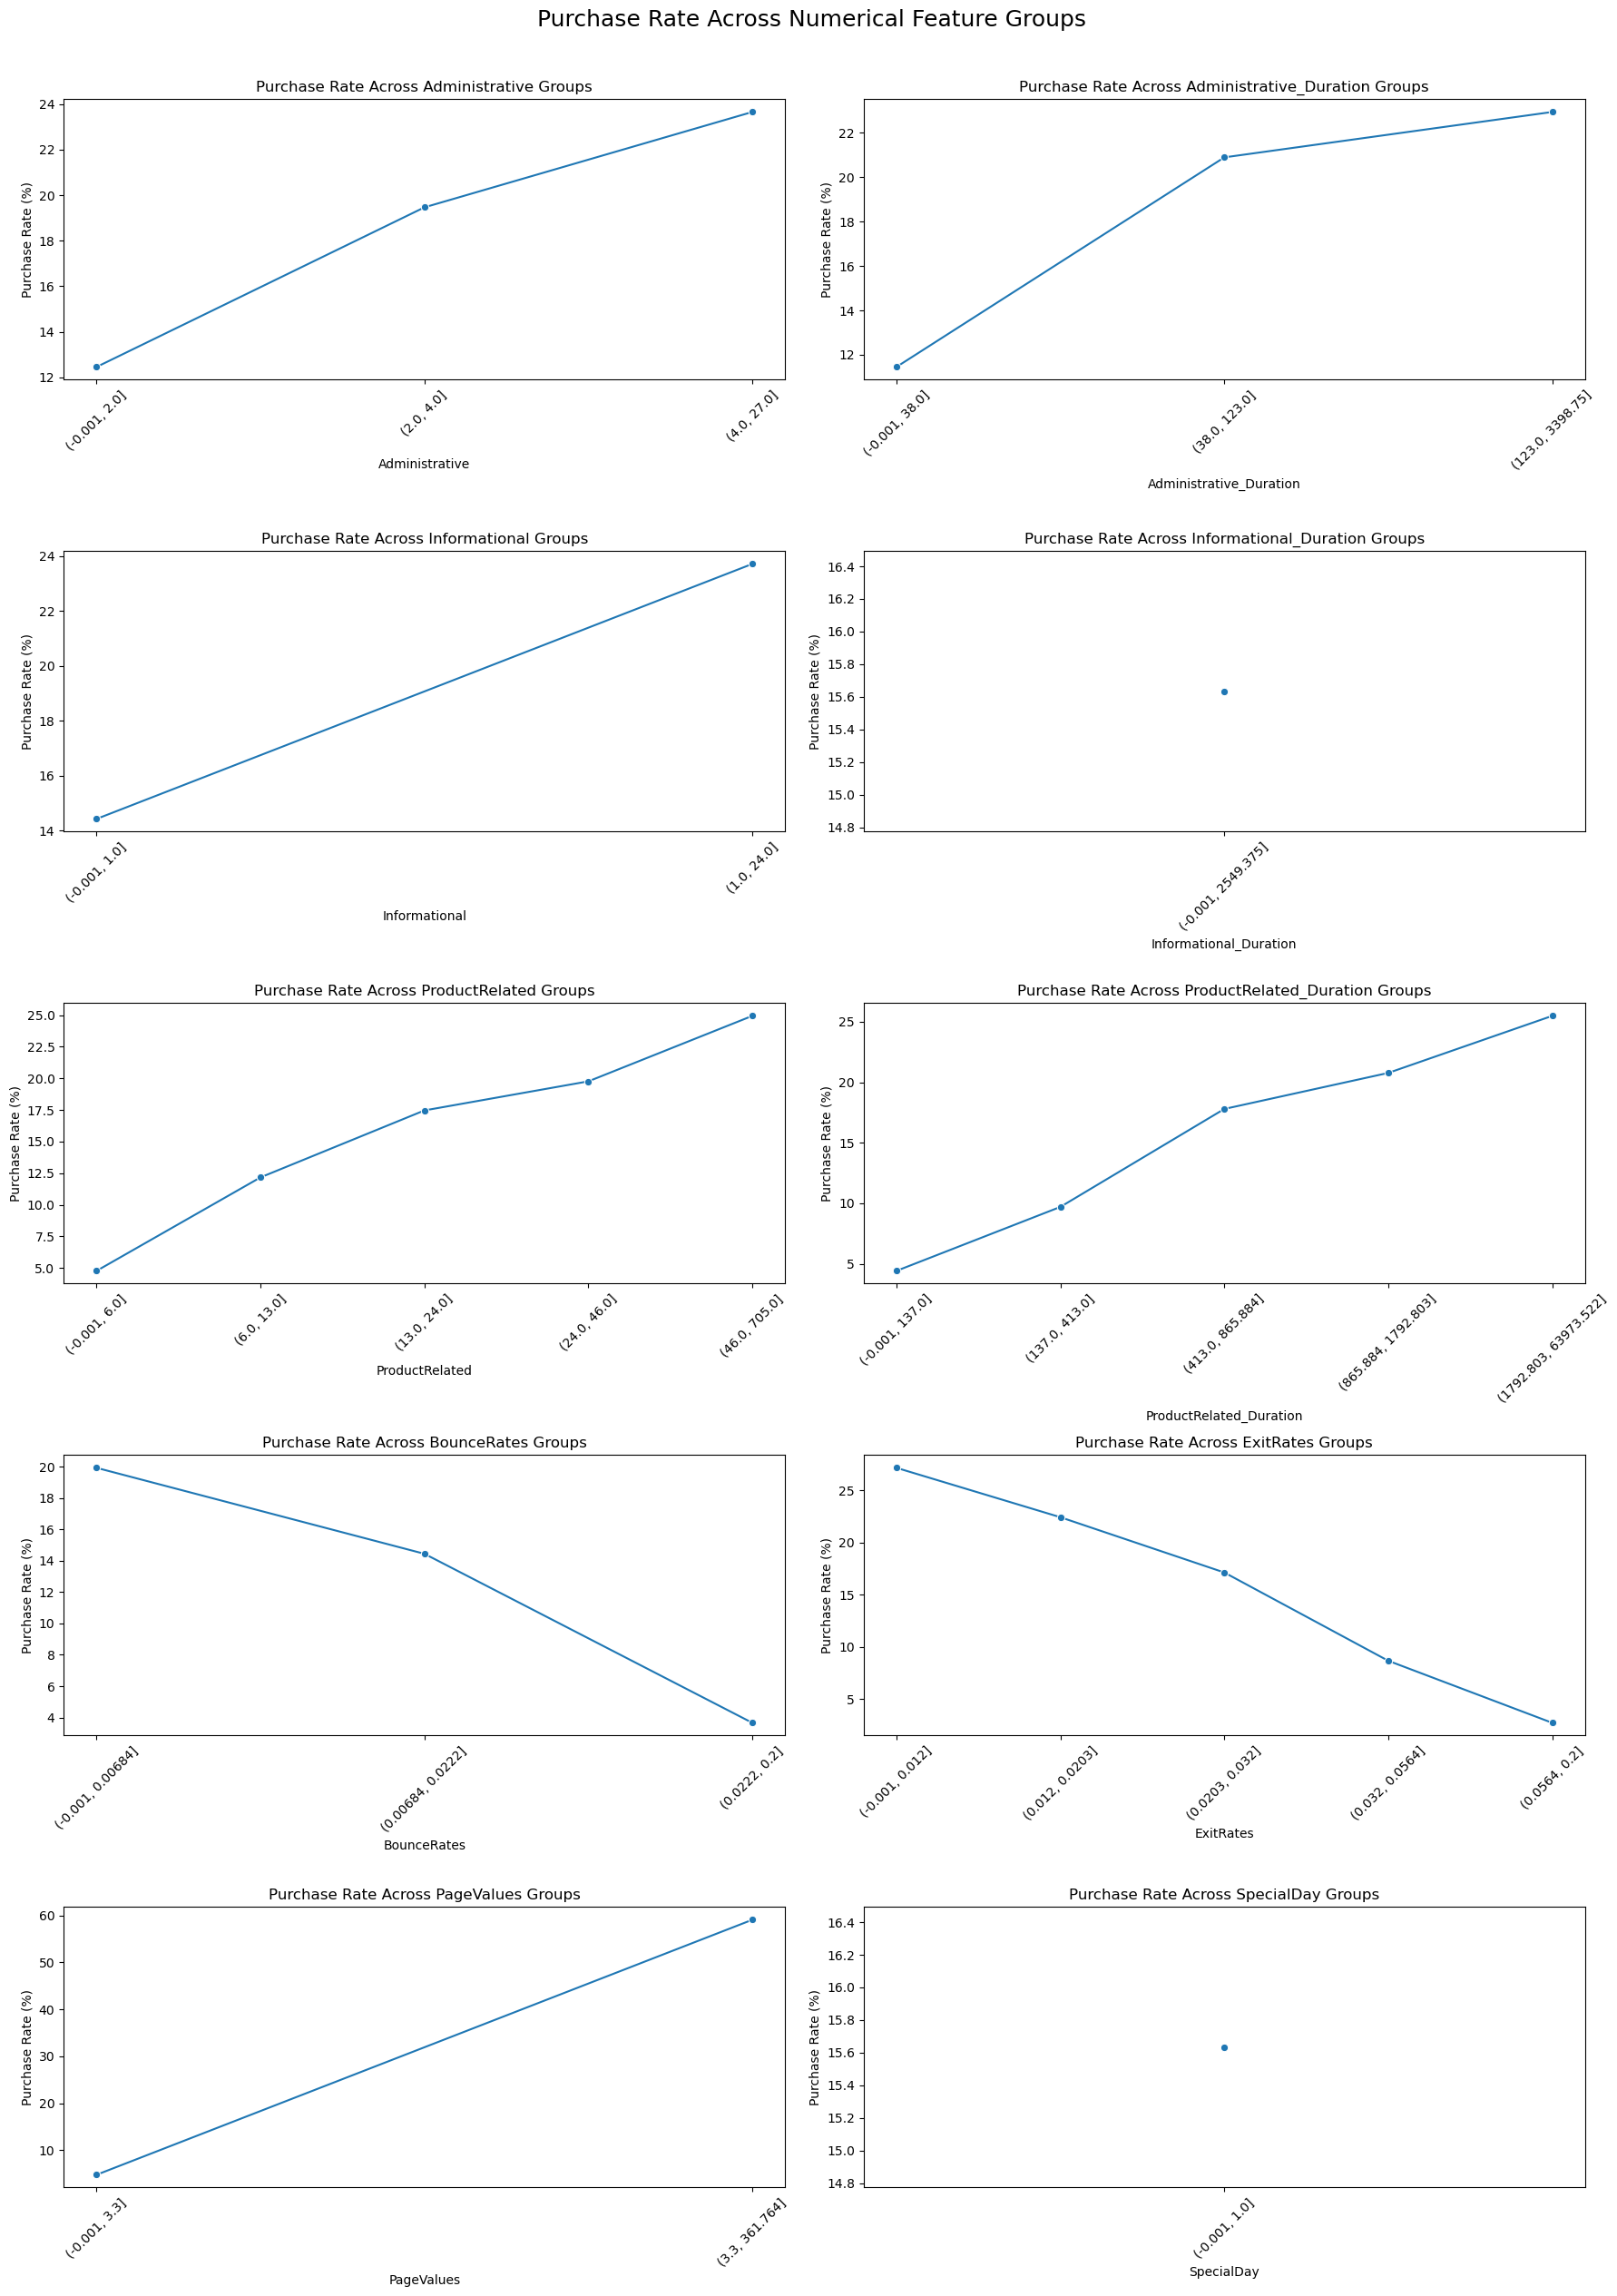

In [24]:
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

df_plot = df.copy()
axes = axes.flatten()

for ax, feature in zip(axes, numeric_cols):

    temp = df_plot[
        [feature, TARGET]
    ].dropna().copy()

    # Check that the feature has enough different values
    if temp[feature].nunique() < 2:
        ax.text(
            0.5,
            0.5,
            "Not enough unique values",
            ha="center",
            va="center"
        )

        ax.set_title(feature)
        continue

    try:
        temp["feature_group"] = pd.qcut(
            temp[feature],
            q=5,
            duplicates="drop"
        )

        summary = (
            temp.groupby(
                "feature_group",
                observed=False
            )[TARGET]
            .agg(
                purchase_rate="mean",
                sample_size="count"
            )
            .reset_index()
        )

        summary["purchase_rate"] *= 100
        summary["group_label"] = (
            summary["feature_group"]
            .astype(str)
        )

        sns.lineplot(
            data=summary,
            x="group_label",
            y="purchase_rate",
            marker="o",
            ax=ax
        )

        ax.set_title(
            f"Purchase Rate Across {feature} Groups"
        )

        ax.set_xlabel(feature)
        ax.set_ylabel("Purchase Rate (%)")
        ax.tick_params(
            axis="x",
            rotation=45
        )

    except ValueError:

        ax.text(
            0.5,
            0.5,
            "Unable to create groups",
            ha="center",
            va="center"
        )

        ax.set_title(feature)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.suptitle(
    "Purchase Rate Across Numerical Feature Groups",
    fontsize=18,
    y=1.01
)

plt.tight_layout()
plt.show()

## insights from the line graph 
 the line graph has provided useful insights for later's features engineering 
 #
 most of them tells me the higher the better beside the exit rate and bounce rate the higher the hard it is 
 #
 to turn that into revenue. Also the PageValue seems the most important features in the features to me

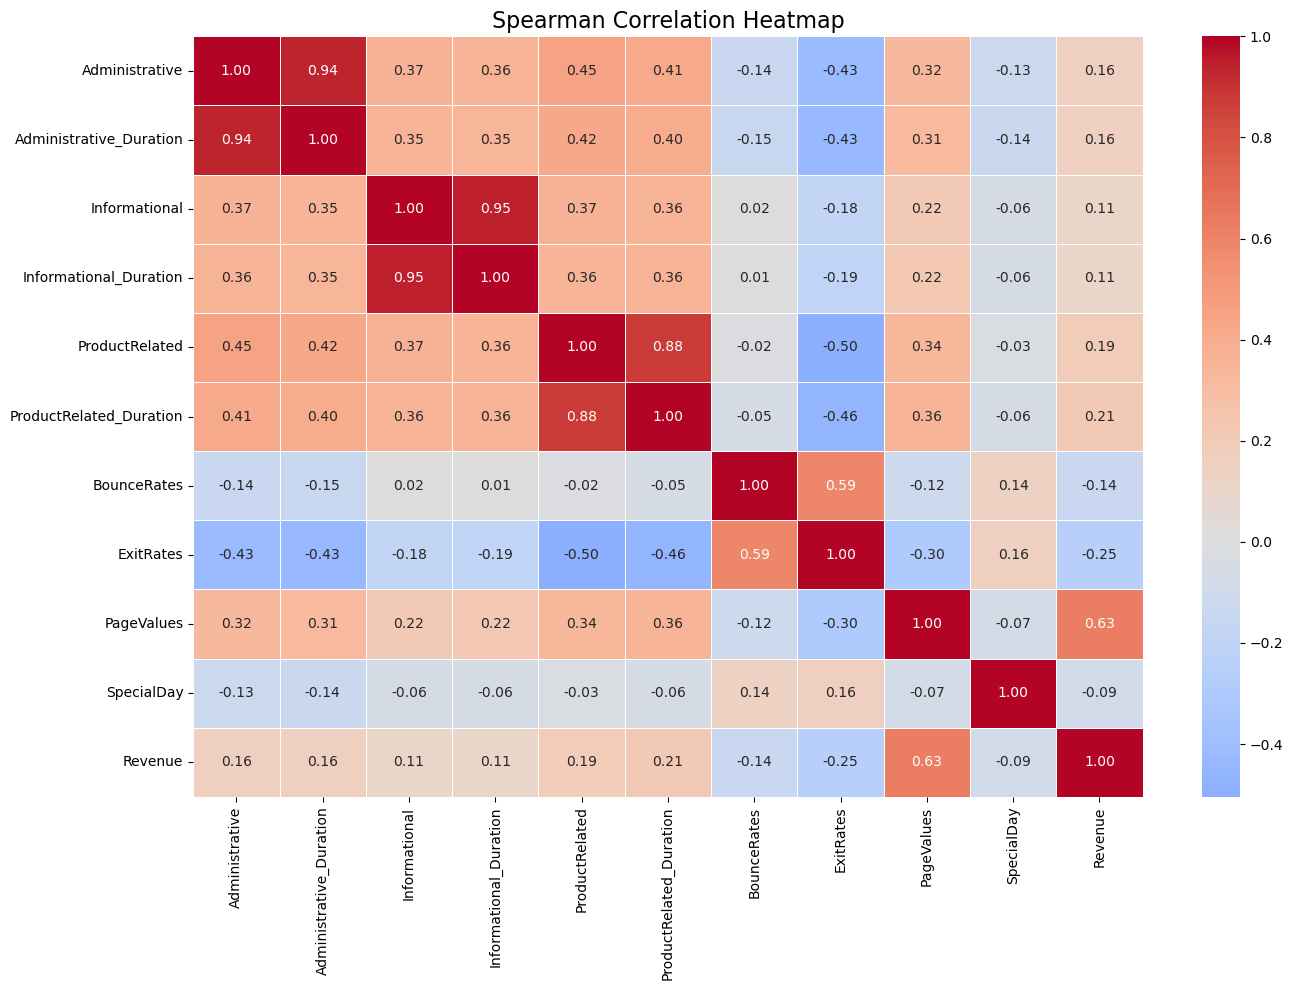

In [25]:
correlation_matrix = (
    df_plot[numeric_cols + [TARGET]]
    .corr(method="spearman")
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Spearman Correlation Heatmap",
    fontsize=16
)

plt.tight_layout()
plt.show()



### Correlation Analysis

The heatmap shows that `Administrative`, `Informational`, and `ProductRelated` are strongly correlated with their corresponding duration features. For example, `Administrative` and `Administrative_Duration` have a correlation of **0.94**, while `Informational` and `Informational_Duration` have a correlation of **0.95**. This is expected because visiting more pages will usually result in a longer total browsing duration nothing too surprising 

However, these strong relationships may introduce **multicollinearity**, especially when using Logistic Regression. Multicollinearity can make the model coefficients less stable and make individual features harder to interpret. During feature engineering, I will test methods such as combining page counts and durations into average-time features, removing one feature from each highly correlated pair, or relying on regularisation. Features should not be removed immediately because page count and total duration may still provide different information.

Among the numerical features, `PageValues` has the strongest relationship with `Revenue`, with a positive correlation of **0.63**. This suggests that sessions with higher page values are more likely to result in a purchase. However, correlation alone does not prove that it is the most important feature, so this will be confirmed later using model-based feature importance or permutation importance.

`ExitRates` has the strongest negative relationship with `Revenue`, with a correlation of **-0.25**. This means that sessions with higher exit rates are generally less likely to result in a purchase. `BounceRates` also has a negative relationship with Revenue, although it is weaker at **-0.14**.

Other features, such as `ProductRelated` and `ProductRelated_Duration`, have small positive correlations with Revenue. This suggests that viewing more product pages and spending more time on products may increase purchase intention, but these relationships are weaker than `PageValues`.

## EDA Exploratory Data Analysis Multivariate Analysis

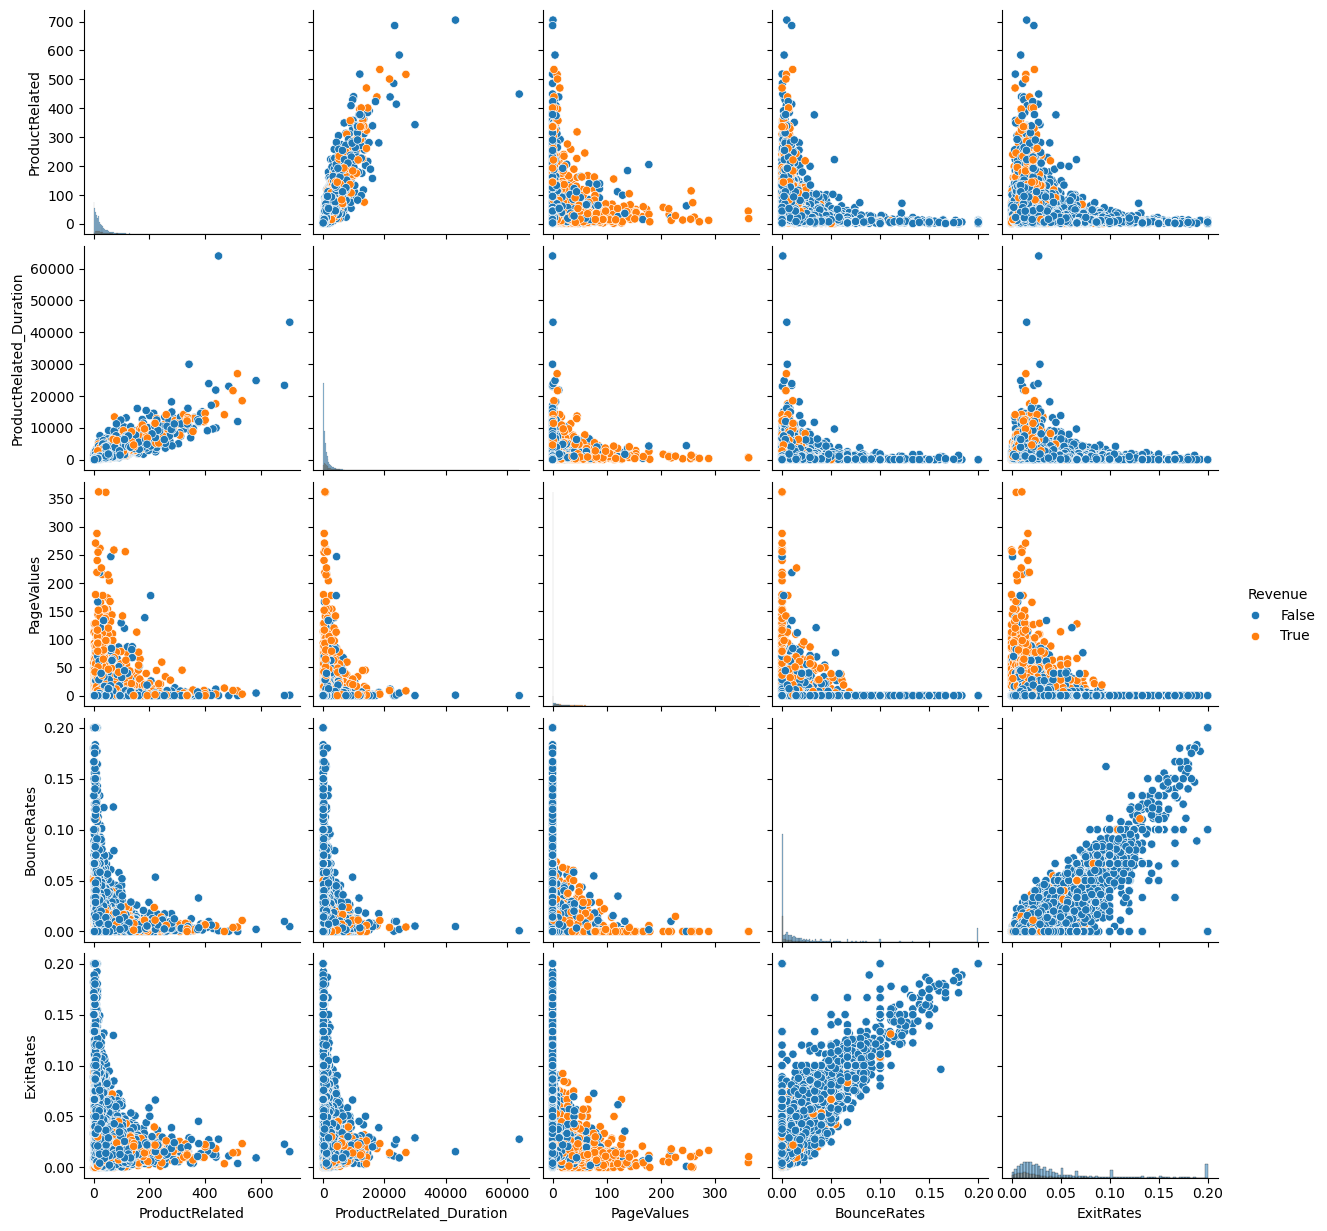

In [26]:
pairplot_cols = [
    'ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates',
    'Revenue'
]

sns.pairplot(
    df[pairplot_cols],
    hue='Revenue',
    diag_kind='hist'
)

plt.show()

# i only pick these few as i felt that these are important features from the passed EDA 
# here it gives me extrem confidnce that PageValues is the single most effective feature. When PageValues > 0, the probability
# of a sale jumps drastically.
# also the exit and bounce rate when high it almost gives no revenue 

## 3.1 Data Cleaning

In [27]:
# from the top we already know the duplactes was cleared, there is no missing and now left with outliers

# variables made for cleaning 
MAX_PRODUCT_PAGES = 450
MAX_PRODUCT_DURATION = 14.5 * 3600  # 14.5 hours in seconds (52,200 seconds)

#  filter out these that are bigger or equaly to the variables we set 
clean_df = df[
    (df['ProductRelated'] <= MAX_PRODUCT_PAGES) & 
    (df['ProductRelated_Duration'] <= MAX_PRODUCT_DURATION)
].copy()

# print verification stats
removed_rows = len(df) - len(clean_df)
print(f"Original total rows: {len(df)}")
print(f"Rows removed: {removed_rows}")
print(f"Cleaned dataset rows: {len(clean_df)}")


Original total rows: 12205
Rows removed: 10
Cleaned dataset rows: 12195


## insights  
<mark> ok good there is only about 10 rows remove even if my domain knowledage was wrong it is still not a bit issue <mark>


## 4.1 Feature engineering 

In [28]:
# features creation 

# average page 
import numpy as np

# Average time spent per Administrative page
df['AvgAdministrativeTime'] = np.where(
    df['Administrative'] > 0,
    df['Administrative_Duration'] /
    df['Administrative'],
    0
)

# Average time spent per Informational page
df['AvgInformationalTime'] = np.where(
    df['Informational'] > 0,
    df['Informational_Duration'] /
    df['Informational'],
    0
)

# Average time spent per Product page
df['AvgProductTime'] = np.where(
    df['ProductRelated'] > 0,
    df['ProductRelated_Duration'] /
    df['ProductRelated'],
    0
)




# decisions on the features creation 
acutally i was thinking not to make any new features but due to the hight correlations in these 6 features i think our plan will be make this and test  which one is the most useful one and drop the others. the others i am not planning to make too much,one of the reason why i dont plan to make too much also because there isn't any other cols that has high correlations,so we will only use these 3 to test out
# 
- also from the eda and data understanding we already know OHE is a must 


# feature transformation
StandardScaler and encodings 
maybe Log Transformation but need to test later 
these are all apply after train test split 

# features extraction (PCA)
#not going to do it since only around 17 features and feature names are meaningful

# features selection 
 we will most likely use the importance and domain knowladge to see which is better then drop the useless features 

## 5.1 Train-Test Split

In [29]:

from sklearn.model_selection import train_test_split


X = df.drop(columns=['Revenue']).copy()

# convert  0/1 the 1 is True and the False is 0
y = df['Revenue'].astype(int).copy()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # 20% test 
    random_state=42,
    stratify=y,
    shuffle=True  # shuffle
)
# this part nothing much 

In [30]:
# Encoding Here we chose one hot encoding, the next suitable is Cyclical encoding but for the purpose of project we keep as OHE
categorical_cols = [
    'Month',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'VisitorType',
    'Weekend'
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# Ensure the test set has exactly the same columns as training
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [31]:
print("Before encoding:", X_train.shape)
print("After encoding:", X_train_encoded.shape)

display(X_train_encoded.head())

# 70 cols is totally ok for the sixe of the dataset 

Before encoding: (9764, 20)
After encoding: (9764, 70)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
7556,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,...,0,0,0,0,0,0,0,0,1,0
11924,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,...,0,0,0,0,0,0,0,0,0,0
3306,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,...,0,0,0,0,0,0,0,0,1,0
207,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,1
4460,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,...,0,0,0,0,0,0,0,0,1,0


# Things we going to do 
1) we going to build one based model 
2) test on 2 different data from out features creation 
3) apply tunning for the based line model 
4) and the rest we will discover more (through the commmit you all should be able to see this is the finial version so i will try to push the model as much as i can and edit and imrpove more things if i can )

## Modeling

In [32]:
from sklearn.linear_model import LogisticRegression


# Create the baseline model.
# max_iter is increased because the dataset contains many features and Logistic Regression may require more iterations

baseline_logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)



baseline_logistic_model.fit(
    X_train_encoded,
    y_train
)

# 0 = No purchase
# 1 = Purchase

baseline_predictions = baseline_logistic_model.predict(
    X_test_encoded
)


# Get the predicted probability of Revenue = 1.
# These probabilities are needed for ROC-AUC and
# Average Precision.

baseline_probabilities = (
    baseline_logistic_model.predict_proba(
        X_test_encoded
    )[:, 1]
)


print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


c:\Users\liaox\anaconda4\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. Model Evaluation

In [33]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
# the dispay is cause i want to show it in table 


# functions 
def evaluate_classification_model(
    y_true,
    y_predictions,
    y_probabilities,
    model_name="Model",
    decision_threshold=0.40 
     # this part i want to test if the dt we changed it to 0.4 does that increases my F2 and other score
):
    

    # Extract values from the confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predictions,
        labels=[0, 1]
    ).ravel()

    # Store confusion matrix results and evaluation metrics
    results = {
        "Model": model_name,

        # Confusion matrix values
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,

        # other evaluation metrics
        "Accuracy": accuracy_score(
            y_true,
            y_predictions
        ),

        "Precision": precision_score(
            y_true,
            y_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            y_predictions,
            zero_division=0
        ),

        "F2 Score": fbeta_score(
            y_true,
            y_predictions,
            beta=2,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_probabilities
        ),

        "Average Precision": average_precision_score(
            y_true,
            y_probabilities
        )
    }

    # convert results into one table
    results_table = pd.DataFrame([results])


    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score",
        "ROC-AUC",
        "Average Precision"
    ]

    results_table[metric_columns] = (
        results_table[metric_columns]
        .round(4)
    )

    results_table = results_table.set_index("Model")
    display(results_table)

    # return the dictionary for later model comparison
    return results

baseline_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=baseline_predictions,
    y_probabilities=baseline_probabilities,
    model_name="Baseline Logistic Regression"
)

,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Baseline Logistic Regression,2007,52,227,155,0.8857,0.7488,0.4058,0.5263,0.4467,0.9074,0.6555


# Explations and matrics decisions

1) Fristlty since i said we going to do a lot of testing making this function as reusalable code is good and easier later 
2) Main Matrics decisions will be F2(explain later)
3) the rest will all be supporting but not the main 

I used F2 as the main is because the business goal is to identify as many potential purchasers as possible. F2 gives more importance to recall than precision, so it penalises the model more heavily when it misses an actual buyer. This is suitable because missing a potential customer may result in a lost sales opportunity, while sending a promotion to a non-buyer is usually less costly. Hence F2 can say overides other matrics. As for this based model the accuracy is high but as what we talk about ealier on the data is imbalance so even if he did not learn anything spamming the False will still give 80plus percent accuracy. Also thewe dont use F1 as F1 gives equal importance to precision and recall. In this project, missing an actual purchaser is more costly than incorrectly predicting that a non-purchaser may buy our main goal is to provide actions when finding a buyer. so F2 is my decision 

In [34]:
# dataset  1 the original dataset 


X_train_original = X_train_encoded.drop(
    columns=[
        'AvgAdministrativeTime',
        'AvgInformationalTime',
        'AvgProductTime'
    ],
    errors='ignore'
)

X_test_original = X_test_encoded.drop(
    columns=[
        'AvgAdministrativeTime',
        'AvgInformationalTime',
        'AvgProductTime'
    ],
    errors='ignore'
)

print(X_train_original.shape)

(9764, 67)


In [35]:
# dataset 2 the featured engineered one 


X_train_engineered = X_train_encoded.drop(
    columns=[
        'Administrative_Duration',
        'Informational_Duration',
        'ProductRelated_Duration','Administrative',
                'Informational',
                'ProductRelated'
    ],
    errors='ignore'
)

X_test_engineered = X_test_encoded.drop(
    columns=[
        'Administrative_Duration',
        'Informational_Duration',
        'ProductRelated_Duration',
        'Administrative',
        'Informational',
        'ProductRelated'
    ],
    errors='ignore'
)

print(X_train_engineered.shape)

(9764, 64)


In [36]:
# log
from sklearn.linear_model import LogisticRegression

model_original = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model_original.fit(
    X_train_original,
    y_train
)

pred_original = model_original.predict(
    X_test_original
)

prob_original = model_original.predict_proba(
    X_test_original
)[:,1]

c:\Users\liaox\anaconda4\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
from sklearn.linear_model import LogisticRegression

# original duration features

model_original = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model_original.fit(
    X_train_original,
    y_train
)
pred_original = model_original.predict(
    X_test_original
)
prob_original = model_original.predict_proba(
    X_test_original
)[:, 1]



#  average time engineered features

model_engineered = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model_engineered.fit(
    X_train_engineered,
    y_train
)

pred_engineered = model_engineered.predict(
    X_test_engineered
)

prob_engineered = model_engineered.predict_proba(
    X_test_engineered
)[:, 1]


original_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_original,
    y_probabilities=prob_original,
    model_name="Original Duration Features"
)

engineered_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_engineered,
    y_probabilities=prob_engineered,
    model_name="Average Time Features"
)


# we had 3 different examples to see for the logistic regression 
# 1) where the model has both the original dataset and the 3 features we created
# 2) only has the orginal dataset
# 3) and only has the features 
# it seems like the one with only original dataset is the best  in terms of the F1 and recall 
# also we will be using 

c:\Users\liaox\anaconda4\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Original Duration Features,2007,52,220,162,0.8886,0.757,0.4241,0.5436,0.465,0.9063,0.6558


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Average Time Features,2011,48,237,145,0.8832,0.7513,0.3796,0.5043,0.4213,0.9012,0.652


# insights we gain 
the engineered model performed worse because average-time features may remove useful information about the customer’s total engagement. For example, two users may have the same average time per page, but one may have viewed many more pages and therefore shown stronger purchase intention, hence we will be using the original data set without the the features engineering dataset, even though at the start we said this will help since their correclation is high but since the result shows otherwise we will follow based on the matrics, this is also the reason why testing is important, next we will do the tunning with the original dataset. so we did follow what i thoguht in the EDA but it seems like the final result proves otherwise so i will just use the original dataset, so there is no change at this part for the dataset 

## Features engineering and Tunning 

In [38]:
#tunning - seach for the best parameters 
from scipy.stats import loguniform
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    make_scorer,
    fbeta_score
)

# F2 scorer: recall has greater importance
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_distributions = {
    "C": loguniform(
        1e-4,
        1e2
    ),

    "penalty": [
        "l1",
        "l2"
    ],

    "solver": [
        "liblinear"
    ],

    "class_weight": [
        None,
        "balanced"
    ]
}

scoring_metrics = {
    "F1": "f1",
    "F2": f2_scorer,
    "Recall": "recall",
    "Precision": "precision",
    "Average_Precision": "average_precision"
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=40,
    scoring=scoring_metrics,
    # here use F2 since our dataset is imbalance and we care about recall more instead of F1 
    refit="F2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)


random_search.fit(
    X_train_original,
    y_train
)



Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': <scipy.stats....002AE99ECFB60>, 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,n_iter,40
,scoring,"{'Average_Precision': 'average_precision', 'F1': 'f1', 'F2': make_scorer(f...ro_division=0), 'Precision': 'precision', ...}"
,n_jobs,-1
,refit,'F2'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### Reasons for the Logistic Regression Parameters

Several Logistic Regression parameters were tuned because the dataset contains many one-hot encoded features and an imbalanced target variable.

the `C` parameter controls how much the model is restricted. A smaller `C` controls the model more strongly and helps reduce overfitting, while a larger `C` allows the model to fit the training data more closely. Different `C` values were tested so RandomizedSearchCV could find the best level of control

the `penalty` parameter controls the model’s coefficients. `L1` can remove weaker features by reducing their coefficients to zero, while `L2` keeps most features but reduces their influence

the `class_weight` parameter helps with the imbalanced target since we do have iut the `None` gives both classes equal importance, while `balanced` gives more importance to the minority purchase class. This may help the model identify more actual buyers and improve recall and F2-score this is used due to our dataset 

The `solver` is the method used to train the Logistic Regression model. 

`max_iter=5000` gives the model enough attempts to finish training without stopping early.


In [ ]:
# training the new model after tunning 

# add parameters 
LogisticRegression(
    C=0.00013289448722869195,
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    max_iter=5000,
    random_state=42
)

# setting  and traininng
best_tuned_model = random_search.best_estimator_
best_tuned_model.fit(X_train_original,
    y_train)

pred_tuned = best_tuned_model.predict(
    X_test_original
)

prob_tuned = best_tuned_model.predict_proba(
    X_test_original
)[:, 1]

In [40]:
# Evaluate the untuned model
untuned_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_original,
    y_probabilities=prob_original,
    model_name="Untuned Logistic Regression"
)

# Evaluate the tuned model
tuned_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_tuned,
    y_probabilities=prob_tuned,
    model_name="F2-Tuned Logistic Regression"
)


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Untuned Logistic Regression,2007,52,220,162,0.8886,0.757,0.4241,0.5436,0.465,0.9063,0.6558


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
F2-Tuned Logistic Regression,1844,215,80,302,0.8791,0.5841,0.7906,0.6719,0.7384,0.8989,0.663


# things to do next and this tunning 
we do not have to worry about the others our main point is F2 the rest are all supporting but for now it seems like the fine tune has helped the modle a lot and making a good improvement, even if there is some drop compared to what we improved it is totally acceptable, and next i am going to see which features are not imporant and remove them and get a final based model then make other models to compare with this base model

In [41]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    best_tuned_model,
    X_test_original,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": X_test_original.columns,
    "Importance": result.importances_mean
})

# sort from most important to least important
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

pd.set_option("display.max_rows", None)

display(importance)

# the RFECV (Recursive Feature Elimination with Cross-Validation) might work well here but i dont quite understand how it works 
# so we will keep with the importance thing 

,Feature,Importance
8,PageValues,0.172716
5,ProductRelated_Duration,0.017042
1,Administrative_Duration,0.005858
0,Administrative,0.002745
26,Browser_2,0.002458
19,OperatingSystems_2,0.002376
65,VisitorType_Returning_Visitor,0.002089
15,Month_May,0.000778
14,Month_Mar,0.000655
10,Month_Dec,0.000492


In [42]:
features_to_remove = [
    "TrafficType_15",
    "Browser_8",
    "Browser_7",
    "OperatingSystems_7",
    "OperatingSystems_6",
    "OperatingSystems_8",
    "Browser_3",
    "Browser_6",
    "Month_June",
    "Month_Feb",
    "OperatingSystems_5",
    "Month_Oct",
    "Month_Sep",
    "Month_Jul",
    "TrafficType_19",
    "TrafficType_16",
    "TrafficType_18",
    "TrafficType_17",
    "TrafficType_9",
    "TrafficType_11",
    "TrafficType_14",
    "Browser_10",
    "Region_7",
    "TrafficType_5",
    "Region_4",
    "Region_8",
    "TrafficType_8",
    "Browser_13",
    "Browser_12",
    "Browser_11",
    "VisitorType_Other",
    "TrafficType_20",
    "TrafficType_7",
    "TrafficType_4",
    "Region_5",
    "Browser_4",
    "Browser_5",
    "Region_6",
    "Weekend_True",
    "OperatingSystems_4",
    "TrafficType_3",
    "Month_Nov"
]

X_train_reduced = X_train_original.drop(
    columns=features_to_remove
)

X_test_reduced = X_test_original.drop(
    columns=features_to_remove
)

print("Original features:", X_train_original.shape[1])
print("Remaining features:", X_train_reduced.shape[1])

model_reduced = LogisticRegression(
    **random_search.best_params_,
    max_iter=5000,
    random_state=42
)

model_reduced.fit(
    X_train_reduced,
    y_train
)

pred_reduced = model_reduced.predict(
    X_test_reduced
)

prob_reduced = model_reduced.predict_proba(
    X_test_reduced
)[:, 1]

Original features: 67
Remaining features: 25


In [43]:
# Evaluate tuned model using all features
tuned_full_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_tuned,
    y_probabilities=prob_tuned,
    model_name="Tuned Full Features"
)

# Evaluate tuned model using reduced features
reduced_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_reduced,
    y_probabilities=prob_reduced,
    model_name="Tuned Reduced Features"
)


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Tuned Full Features,1844,215,80,302,0.8791,0.5841,0.7906,0.6719,0.7384,0.8989,0.663


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Tuned Reduced Features,1845,214,80,302,0.8796,0.5853,0.7906,0.6726,0.7387,0.8942,0.6597


### Feature Reduction Testing

here, I tested several different feature reduction methods. First, I removed all features with negative importance, then all features with zero importance, and then both negative and zero-importance features together.

i also tested removing the negative and zero importance features while keeping `BounceRates`, `ExitRates`, `Informational`, and `ProductRelated`, as I believe these features are still important based on the eda and business understanding.(these comes under domain knowleadge where i feel that these features might provide some imporant informations so i tried keeping them)
among all the feature reduction methods tested, this version gave the best result. Although the improvement was small, it still performed slightly better than the other reduced feature sets. so for the features engineering for this part my decision is to clear but with domain knowleadge which the result proves it worked 

## summary of the final logistic modle 

In [44]:
# 1. Baseline model
baseline_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=baseline_predictions,
    y_probabilities=baseline_probabilities,
    model_name="1. Baseline Logistic Regression"
)

# 2. Original duration features
original_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_original,
    y_probabilities=prob_original,
    model_name="2. Original Duration Features"
)

# 3. Engineered average-time features
engineered_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_engineered,
    y_probabilities=prob_engineered,
    model_name="3. Average Time Features"
)

# 4. Tuned Logistic Regression
tuned_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_tuned,
    y_probabilities=prob_tuned,
    model_name="4. F2-Tuned Logistic Regression"
)

# 5. Final reduced-feature model
reduced_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_reduced,
    y_probabilities=prob_reduced,
    model_name="5. Reduced Features - Final Model"
)


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
1. Baseline Logistic Regression,2007,52,227,155,0.8857,0.7488,0.4058,0.5263,0.4467,0.9074,0.6555


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
2. Original Duration Features,2007,52,220,162,0.8886,0.757,0.4241,0.5436,0.465,0.9063,0.6558


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
3. Average Time Features,2011,48,237,145,0.8832,0.7513,0.3796,0.5043,0.4213,0.9012,0.652


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
4. F2-Tuned Logistic Regression,1844,215,80,302,0.8791,0.5841,0.7906,0.6719,0.7384,0.8989,0.663


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
5. Reduced Features - Final Model,1845,214,80,302,0.8796,0.5853,0.7906,0.6726,0.7387,0.8942,0.6597


### Overall Model Development and Comparison

1) **baseline Logistic Regression** achieved high accuracy and precision, but its recall was only **40.58%**. It identified only **155 out of 382 purchasers** and missed **227 actual buyers**, which showex that the baseline model was too conservative and predicted False too often.

2) next i tested the **original duration features** against the engineered **average-time features**. The original feature model performed better, with a higher recall of **42.41%** and F2-score of **0.4650**. The average-time features reduced useful information about the customer’s total browsing activity, causing recall and F2-score to decrease. Therefore, the original duration features were kept.

3) I used **RandomizedSearchCV** to tune the Logistic Regression model based on F2-score. The tuned model improved recall greatly from **42.41% to 79.06%** and increased the F2-score from **0.4650 to 0.7384**. It correctly identified **302 purchasers** and reduced the number of missed buyers from **220 to 80** but, precision decreased because the model predicted more customers as potential purchasers, resulting in more false positives, the trade off to me is ok since we push the F2 score up which the main goal is to find more cutomer 

4) I tested different feature-reduction methods by removing features with negative or zero importance while keeping features that were considered meaningful based on EDA and domain knowledge the final reduced feature model achieved the highest F2-score of **0.7387**, while maintaining the same recall of **79.06%**, it also slightly improved precision, F1-score and accuracy compared with the tuned full-feature model.

**Model development process:**  
Baseline model → Compare original and engineered features → Tune hyperparameters using F2-score → Reduce less useful features → Select final model

-next if we still want to improve we need do more tunning and maybe change the decision threshold

result: i tried to changed the decision threshold but it seems like the result did not make any changes but the 73.87% for the F2 score is pretty ok for me already Hence we will keep this as the final logistic modle 

In [45]:
# what to do next 
# use tree models and supposed the tree modles is better, try the trees without tun then pick the best one and tun it 
# use the tun one compared with the logistic model we made on top 

In [52]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.utils.class_weight import (
    compute_sample_weight
)


# Creating the models

tree_models = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=20,
        random_state=42
    )
}




balanced_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


# train and evaluate the models
tree_results = []

trained_tree_models = {}

tree_predictions = {}

tree_probabilities = {}


for model_name, model in tree_models.items():

    # Gradient Boosting does not have class_weight,
    # so balanced sample weights are used instead.
    if model_name == "Gradient Boosting":

        model.fit(
            X_train_reduced,
            y_train,
            sample_weight=balanced_sample_weights
        )

    else:

        model.fit(
            X_train_reduced,
            y_train
        )


    predictions = model.predict(
        X_test_reduced
    )


    probabilities = model.predict_proba(
        X_test_reduced
    )[:, 1]

    # Save models and predictions
    trained_tree_models[model_name] = model

    tree_predictions[model_name] = predictions

    tree_probabilities[model_name] = probabilities

    # evaluate model
    model_results = evaluate_classification_model(
        y_true=y_test,
        y_predictions=predictions,
        y_probabilities=probabilities,
        model_name=model_name,
        show_table=False
    )

    tree_results.append(
        model_results
    )



# compare the three tree-based models


model_comparison = pd.DataFrame(
    tree_results
)


comparison_columns = [
    "Model",
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "F2 Score",
    "ROC-AUC",
    "Average Precision"
]


model_comparison = (
    model_comparison[comparison_columns]
    .set_index("Model")
    .sort_values(
        by="F2 Score",
        ascending=False
    )
)


display(
    model_comparison.round(4)
)

,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Gradient Boosting,1805,254,64,318,0.8697,0.5559,0.8325,0.6667,0.7571,0.9274,0.7246
Random Forest,1983,76,168,214,0.9000,0.7379,0.5602,0.6369,0.5886,0.9200,0.7269
Decision Tree,1893,166,184,198,0.8566,0.5440,0.5183,0.5308,0.5233,0.7186,0.3573


# Things to do next 

from the result we go i had a big suprised from the trees models based on our main matrics the F2 for the greadient boosting is already the best modle 
what we will do is because this is a add on as i want to try more modles the randome forest i already trained so i will keep and make a 3rd modle GB but most liekly the GB will be the best 

## also why i choose these models 
After using Logistic Regression as the baseline, tree-based models were tested to provide **model diversity** and determine whether a different type of algorithm could better capture customer purchasing behaviour. This also meets the project requirement to train multiple distinct algorithms, compare them with a baseline, and justify the final model using test results and business needs. :contentReference[oaicite:0]{index=0}

Logistic Regression mainly learns a linear relationship between the features and purchase probability. However, customer behaviour may involve more complex relationships. For example, a high `PageValues` score may only strongly indicate a purchase when it is combined with a low `ExitRates` value and high product-page engagement.
Tree-based models were therefore selected because they can:
- Learn non-linear relationships between browsing behaviour and purchase intention.
- Automatically capture interactions between different features.
- Handle skewed numerical data without requiring scaling.
- Work with both numerical and one-hot encoded categorical features.
- Produce purchase probabilities using `predict_proba()` for deployment.

Three tree-based algorithms were tested:
**Decision Tree** was used as a simple and interpretable tree baseline. Its decisions can be followed as a series of rules, but a single tree can easily overfit and may be unstable.
**Random Forest** combines many independent decision trees and averages their results. This reduces overfitting and usually produces more stable predictions than a single Decision Tree.
**Gradient Boosting** builds trees one after another, with each new tree attempting to correct the earlier model’s mistakes. This allows it to learn difficult and complex purchasing patterns more effectively.




In [53]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    make_scorer,
    fbeta_score
)



# 1. create F2 scorer


f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)


# 2. Create stratified cross-validation


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# 3. Create base Random Forest


rf_model = RandomForestClassifier(
    random_state=42,

    # Keep this at 1 because RandomizedSearchCV
    # is already running models in parallel
    n_jobs=1
)


#  Parameters to test
# Maximum of 3 values for each hyperparameter

rf_param_distributions = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        10,
        20
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2",
        0.5
    ],

    "class_weight": [
        "balanced",
        "balanced_subsample",
        {
            0: 1,
            1: 3
        }
    ]
}


# 5. Create RandomizedSearchCV


rf_random_search = RandomizedSearchCV(
    estimator=rf_model,

    param_distributions=rf_param_distributions,

    # 15 combinations × 5 folds = 75 model fits
    n_iter=15,

    scoring=f2_scorer,

    cv=cv,

    refit=True,

    random_state=42,

    # Parallelise the search instead of each forest
    n_jobs=-1,

    # Prevent too many jobs from being created at once
    pre_dispatch="2*n_jobs",

    verbose=2,

    return_train_score=False
)



# 6. Run the search using training data only


rf_random_search.fit(
    X_train_reduced,
    y_train
)



# 7. Show best cross-validation result


print(
    "Best Parameters:"
)

print(
    rf_random_search.best_params_
)

print(
    "\nBest Cross-Validation F2 Score:",
    round(
        rf_random_search.best_score_,
        4
    )
)



# 8. Get the best tuned Random Forest


best_rf_model = rf_random_search.best_estimator_



# 9. Make final test predictions


pred_rf_tuned = best_rf_model.predict(
    X_test_reduced
)

prob_rf_tuned = best_rf_model.predict_proba(
    X_test_reduced
)[:, 1]



# 10. Evaluate using your existing function


tuned_rf_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_rf_tuned,
    y_probabilities=prob_rf_tuned,
    model_name="F2-Tuned Random Forest",
    show_table=True
)




Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced_subsample'}

Best Cross-Validation F2 Score: 0.7407


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
F2-Tuned Random Forest,1847,212,76,306,0.882,0.5907,0.801,0.68,0.7478,0.927,0.7282


In [58]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    make_scorer,
    fbeta_score
)


# =========================================================
# 1. Create F2 scorer
# =========================================================

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)


# =========================================================
# 2. Create stratified cross-validation
# =========================================================

gb_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 3. Create a new Gradient Boosting model for tuning
# =========================================================

gb_model_for_tuning = GradientBoostingClassifier(
    random_state=42
)


# =========================================================
# 4. Define parameters to test
# Maximum of 3 values for each parameter
# =========================================================

gb_param_distributions = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "learning_rate": [
        0.05,
        0.1,
        0.2
    ],

    "max_depth": [
        2,
        3,
        5
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        10,
        20,
        30
    ],

    "subsample": [
        0.7,
        0.85,
        1.0
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ]
}


# =========================================================
# 5. Create RandomizedSearchCV
# =========================================================

gb_random_search = RandomizedSearchCV(
    estimator=gb_model_for_tuning,

    param_distributions=gb_param_distributions,

    # 15 combinations × 5 folds = 75 fits
    n_iter=15,

    scoring=f2_scorer,

    cv=gb_cv,

    refit=True,

    random_state=42,

    n_jobs=-1,

    verbose=2,

    return_train_score=False
)


# =========================================================
# 6. Run the tuning using training data only
# =========================================================

gb_random_search.fit(
    X_train_reduced,
    y_train,
    sample_weight=balanced_sample_weights
)


# =========================================================
# 7. Show the best tuning results
# =========================================================

print("Best Parameters:")

print(
    gb_random_search.best_params_
)

print(
    "\nBest Cross-Validation F2 Score:",
    round(
        gb_random_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': 2, 'learning_rate': 0.1}

Best Cross-Validation F2 Score: 0.8257


In [66]:
# does not have a class_weight parameter
balanced_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


# Create Gradient Boosting model using the best parameters
best_gb_model = GradientBoostingClassifier(
    subsample=1.0,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=20,
    max_features="log2",
    max_depth=2,
    learning_rate=0.1,
    random_state=42
)


# Train the model
best_gb_model.fit(
    X_train_reduced,
    y_train,
    sample_weight=balanced_sample_weights
)


# Make predictions
pred_best_gb = best_gb_model.predict(
    X_test_reduced
)


# Get purchase probabilities
prob_best_gb = best_gb_model.predict_proba(
    X_test_reduced
)[:, 1]


# Evaluate using your existing function
best_gb_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_best_gb,
    y_probabilities=prob_best_gb,
    model_name="Best-Parameter Gradient Boosting",
    show_table=True
)

,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Best-Parameter Gradient Boosting,1810,249,66,316,0.871,0.5593,0.8272,0.6674,0.7549,0.9303,0.7308


# suprised result 
after the tunning i see that the based line model seems to be better then the tune model 

In [67]:
# all modles compared 

# logistc
reduced_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_reduced,
    y_probabilities=prob_reduced,
    model_name="5. Reduced Features - Final Model"
)

# RF
tuned_rf_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=pred_rf_tuned,
    y_probabilities=prob_rf_tuned,
    model_name="F2-Tuned Random Forest",
    show_table=True
)

# based line GB
baseline_gb_results = evaluate_classification_model(
    y_true=y_test,
    y_predictions=tree_predictions[
        "Gradient Boosting"
    ],
    y_probabilities=tree_probabilities[
        "Gradient Boosting"
    ],
    model_name="Baseline Gradient Boosting",
    show_table=True
)


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
5. Reduced Features - Final Model,1845,214,80,302,0.8796,0.5853,0.7906,0.6726,0.7387,0.8942,0.6597


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
F2-Tuned Random Forest,1847,212,76,306,0.882,0.5907,0.801,0.68,0.7478,0.927,0.7282


,True Negative,False Positive,False Negative,True Positive,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,Average Precision
Model,,,,,,,,,,,
Baseline Gradient Boosting,1805,254,64,318,0.8697,0.5559,0.8325,0.6667,0.7571,0.9274,0.7246


# Overall summary on the modles 

- so i tested out the logistic model , we realized that the original dataset was good better,then we did tunning and features reduction for the engineering part whihc achineve a **73,87** for the main matrics F2 
- next i also train 3 based tree model and the RF and GB stands out espically the GB considering the natural of the GB it is normally that it will performe well but after the tunning the RF result imrpoved quit a lot and the GB did not instead it actually drop for the F2.

### Why Tuning Did Not Improve the F2-Score

After tuning, the Gradient Boosting model's F2-score decreased slightly from **0.7571 to 0.7549**. RandomizedSearchCV selected the parameters that achieved the best average F2-score across the training folds, but this does not guarantee that they will perform better on the unseen test set.
The baseline parameters were already suitable for this dataset. The tuned model became slightly more conservative, identifying **316 purchasers instead of 318** and increasing the number of missed purchasers from **64 to 66**. Since recall is important for the F2-score, this small decrease caused the tuned model's F2-score to become slightly lower.
The difference is very small, so tuning did not fail. It simply showed that the original Gradient Boosting settings generalised slightly better to the test data. Therefore, the baseline model was kept.

### Quantitative Comparison

| Model | Recall | F2 Score | ROC-AUC | Average Precision |
|---|---:|---:|---:|---:|
| Reduced Logistic Regression | 0.7906 | 0.7387 | 0.8942 | 0.6597 |
| F2-Tuned Random Forest | 0.8010 | 0.7478 | 0.9270 | 0.7282 |
| Baseline Gradient Boosting | **0.8325** | **0.7571** | **0.9274** | 0.7246 |
| Decision Tree | 0.5183 | 0.5233 | 0.7186 | 0.3573 |

The Decision Tree produced the weakest results, suggesting that one tree was not stable enough for this dataset. Random Forest improved performance by combining many trees and performed better than Logistic Regression in F2-score, recall, ROC-AUC and Average Precision.

Gradient Boosting achieved the highest **recall of 83.25%** and the highest **F2-score of 0.7571**. It correctly identified 318 purchasing sessions and missed only 64 purchasers. Although it produced more false-positive predictions and had slightly lower accuracy than Random Forest, this trade-off is acceptable because missing a potential purchaser is more costly to the business than sending a promotion to a customer who may not purchase.

Therefore, the **Baseline Gradient Boosting model was selected as the final model** because it performed best according to the main business metric and was most effective at identifying potential buyers. It can also be saved using Joblib and deployed in the Streamlit application to return both a purchase classification and probability percentage.

## summary 

All in All we will use the Baseline Gradient Boosting as the main and final model for this project. since it has the highest F2 of **75.71** and beside precision all the other scroces are also at a good level,therefore we will pick that as the model 

In [ ]:
# importing the model 

import joblib


# Get the trained baseline Gradient Boosting model
final_model = trained_tree_models[
    "Gradient Boosting"
]


# Save the model together with the required information
model_bundle = {
    "model": final_model,

    "feature_columns": X_train_reduced.columns.tolist(),
    "threshold": 0.50,

    "model_name": "Baseline Gradient Boosting"
}


joblib.dump(
    model_bundle,
    "Online_shopper_intention_GB_model"
)

print(
    "Baseline Gradient Boosting model saved successfully."
)

Baseline Gradient Boosting model saved successfully.


In [ ]:
# testing later 
# make sure the when using the real data my result is the same as the real dataset 
# also add in the check for overfitting 


In [ ]:
# this is for the version problem when i deploy 
import sys
import sklearn
import joblib
import numpy
import pandas

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

Python: 3.13.0 | packaged by Anaconda, Inc. | (main, Oct  7 2024, 21:21:52) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.7.1
joblib: 1.5.3
numpy: 2.4.4
pandas: 2.3.3
